In [2]:
using Pkg
Pkg.activate("./")
Pkg.develop(path="../../")
Pkg.develop(path="../../../TauRunner/TauRunner.jl/")
ENV["TAMBOSIM_PATH"] = realpath("../../")

  Activating project at `~/research/TAMBO-MC/notebooks/create_geometry`
   Resolving package versions...
    Updating `~/research/TAMBO-MC/notebooks/create_geometry/Project.toml`
  [37e2e46d] ↓ LinearAlgebra v1.12.0 ⇒ v1.11.0
    Updating `~/research/TAMBO-MC/notebooks/create_geometry/Manifest.toml`
  [ac6e5ff7] - JuliaSyntaxHighlighting v1.12.0
⌅ [aea7be01] ↓ PrecompileTools v1.3.3 ⇒ v1.2.1
⌅ [17f450c3] ↓ LAPACK32_jll v3.12.1+1 ⇒ v3.12.0+1
  [458c3c95] ↑ OpenSSL_jll v3.5.1+0 ⇒ v3.5.4+0
  [37e2e46d] ↓ LinearAlgebra v1.12.0 ⇒ v1.11.0
  [ca575930] ↓ NetworkOptions v1.3.0 ⇒ v1.2.0
  [44cfe95a] ↓ Pkg v1.12.0 ⇒ v1.11.0
  [2f01184e] ↓ SparseArrays v1.12.0 ⇒ v1.11.0
  [e66e0078] ↓ CompilerSupportLibraries_jll v1.3.0+1 ⇒ v1.1.1+0
  [deac9b47] ↓ LibCURL_jll v8.11.1+1 ⇒ v8.6.0+0
  [e37daf67] ↓ LibGit2_jll v1.9.0+0 ⇒ v1.7.2+0
  [29816b5a] ↓ LibSSH2_jll v1.11.3+1 ⇒ v1.11.0+1
  [c8ffd9c3] ↓ MbedTLS_jll v2.28.1010+0 ⇒ v2.28.6+0
  [14a3606d] ↓ MozillaCACerts_jll v2025.5.20 ⇒ v2023.12.12
  [4536629a] 

"/Users/jlazar/research/TAMBO-MC"

In [4]:
using Tambo
using Makie
using CairoMakie
using HDF5
using LinearAlgebra
using Unitful
using StatsBase
include("../plotting_boilerplate.jl")

[ Info: PROPOSAL.jl loaded successfully


Welcome to TAMBOSim version -0.1
Git commit hash: bc7c8bf32156a9f2fa3384e9d8436c116379003d
              /\    //\
             { `---'  }
             {  O   O  }
      _      {  \     /}     __
    /  \     `._`---'_/     /  \
   /  | \  ν_τ  `~.~`  ν_τ /  | \
  /   |  \     _.-'-.     /   |  \
 /    |   \ .'       `.  /    |   \
/     |    /           \/     |    \ 
████████╗ █████╗ ███╗   ███╗██████╗  ██████╗
╚══██╔══╝██╔══██╗████╗ ████║██╔══██╗██╔═══██╗
   ██║   ███████║██╔████╔██║██████╔╝██║   ██║
   ██║   ██╔══██║██║╚██╔╝██║██╔══██╗██║   ██║
   ██║   ██║  ██║██║ ╚═╝ ██║██████╔╝╚██████╔╝
   ╚═╝   ╚═╝  ╚═╝╚═╝     ╚═╝╚═════╝  ╚═════╝
                                             


In [5]:
filename = "./triangulation.h5"
key = "colca_valley_30000"

earth = Tambo.Earth("$(filename):$(key)")
enu_coordinates = Tambo.CoordinateSystem(earth)

CoordinateSystem{Float64}(origin: [1867.54, -5844.519, -1715.673] km)

In [6]:
outline = Tuple{Float64, Float64}[]
for line in readlines("./TAMBO_outline.csv")
    long, lat = deg2rad.(parse.(Float64, split(line, ", ")))
    push!(outline, (long, lat))
end
    
# This need to be oriented anti-clockwise
cog = [sum([x[1] for x in outline]), sum([x[2] for x in outline])] ./ length(outline)
phis = []
for (x,y) in outline
    push!(phis, atan(y-cog[2], x-cog[1]))
end
sorter = sortperm(phis)
outline = outline[sorter]

27-element Vector{Tuple{Float64, Float64}}:
 (-1.2616995870208432, -0.2726715154780103)
 (-1.2616953040042738, -0.2727202334080829)
 (-1.261682454954566, -0.2727617576410753)
 (-1.261620351214311, -0.27291886245169455)
 (-1.261588228590041, -0.27297577012921237)
 (-1.2615636012447675, -0.27305340395474104)
 (-1.2613954928444222, -0.2730529363644308)
 (-1.2613783607781448, -0.2730241173072047)
 (-1.261352662678729, -0.2729808887213656)
 (-1.261339813629021, -0.27293582297596447)
 (-1.2613312475958824, -0.27284745117414033)
 (-1.261339813629021, -0.27279691821895824)
 (-1.261352662678729, -0.2727553939859658)
 ⋮
 (-1.2613805022864297, -0.2725027679453473)
 (-1.2613269645793133, -0.272441571717647)
 (-1.26131625703789, -0.27237485294403435)
 (-1.261375148515718, -0.27227097319138915)
 (-1.2614297569769766, -0.2722708320842541)
 (-1.2614961437338008, -0.2722715625211884)
 (-1.261706011545697, -0.2722827459533416)
 (-1.2617723983025213, -0.27233218325312225)
 (-1.2618323605344919, -0.272384

In [17]:
coords = Tambo.Coordinate[]
for longlat in outline
    x, y, z = Tambo.longlat_to_cart(longlat...) .* earth.prem[end].radius
    c = Tambo.Coordinate(x, y, z, Tambo.ecefcoordinates)
    c = convert(enu_coordinates, c)
    push!(coords, c)
end
coords = coords[1:end-5]

22-element Vector{Coordinate}:
 Coordinate{Float64}([-1142.01, -73.42, -0.1] m)
 Coordinate{Float64}([-1115.72, -383.8, -0.11] m)
 Coordinate{Float64}([-1036.87, -648.35, -0.12] m)
 Coordinate{Float64}([-655.8, -1649.25, -0.25] m)
 Coordinate{Float64}([-458.72, -2011.8, -0.33] m)
 Coordinate{Float64}([-307.62, -2506.41, -0.5] m)
 Coordinate{Float64}([723.72, -2503.44, -0.53] m)
 Coordinate{Float64}([828.83, -2319.83, -0.48] m)
 Coordinate{Float64}([986.5, -2044.43, -0.4] m)
 Coordinate{Float64}([1065.34, -1757.32, -0.33] m)
 Coordinate{Float64}([1117.93, -1194.31, -0.21] m)
 Coordinate{Float64}([1065.39, -872.36, -0.15] m)
 Coordinate{Float64}([986.56, -607.8, -0.11] m)
 Coordinate{Float64}([973.46, 139.28, -0.08] m)
 Coordinate{Float64}([881.49, 564.77, -0.09] m)
 Coordinate{Float64}([815.81, 1001.68, -0.13] m)
 Coordinate{Float64}([1144.33, 1391.55, -0.25] m)
 Coordinate{Float64}([1210.06, 1816.61, -0.37] m)
 Coordinate{Float64}([848.72, 2478.45, -0.54] m)
 Coordinate{Float64}([513.6

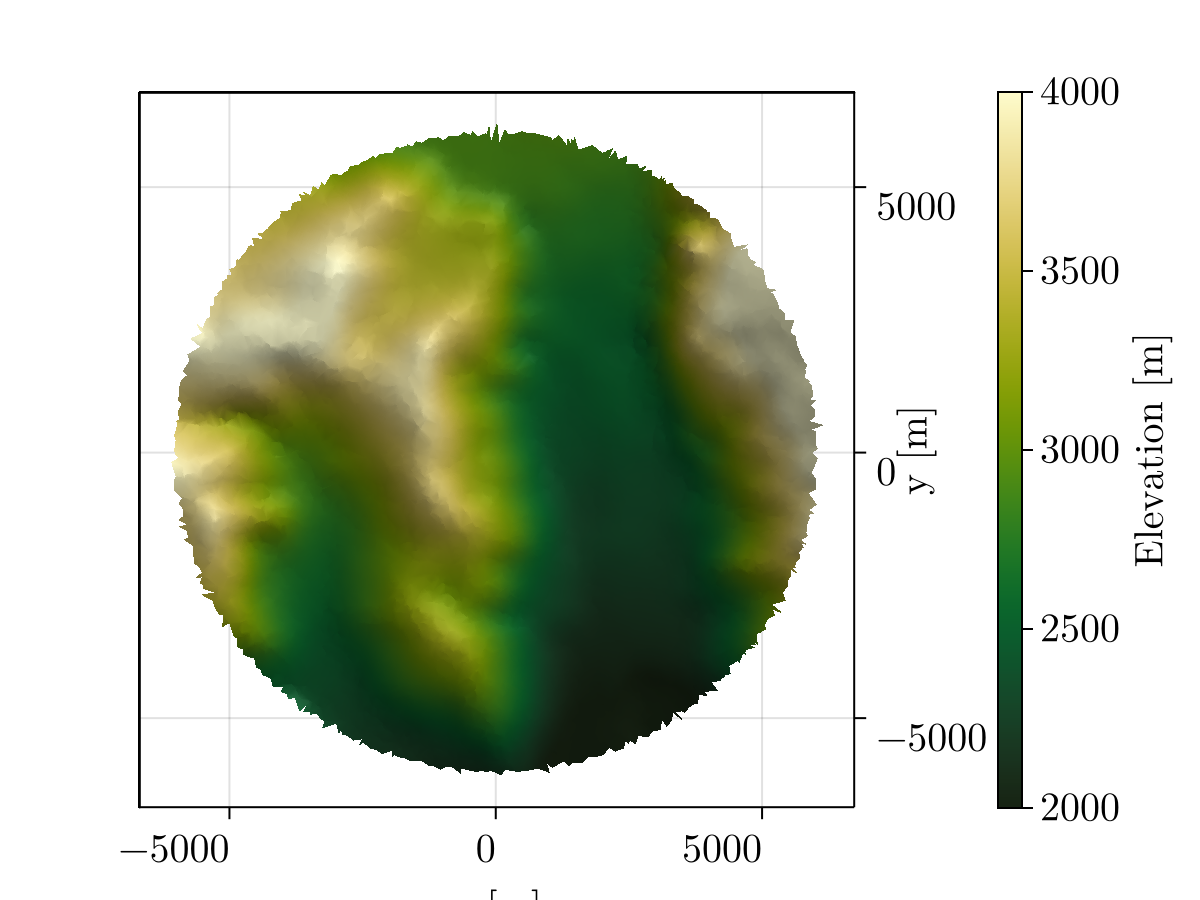

CairoMakie.Screen{IMAGE}


In [19]:
radius = 6 * u"km"
fig = Figure()

triangles = filter(triangle->norm(Tambo.centroid(triangle)[1:2]) < radius, earth.topography)
triangles = filter(triangle->Tambo.centroid(triangle)[3] > 0 * u"km", triangles)

vxs, faces = Tambo.triangles_to_mesh(triangles)

zaspect = 4500*Tambo.uparse("m") / (2 * radius)

ax = Axis3(
    fig[1, 1],
    azimuth=deg2rad(-90),
    elevation=deg2rad(90),
    aspect=(1, 1, zaspect),
    zgridvisible=false,
    zlabelvisible=false,
    zticklabelsvisible=false,
    zticksvisible=false,
    xlabel="x [m]",
    ylabel="y [m]",
)
zlims!(ax, 1000, 5500)

m = mesh!(
    ax,
    map(vx->Point3f(ustrip.(vx.point)), vxs),
    faces,
    color=[v.point.z.val for v in vxs],
    colormap=Reverse(:speed),
    colorrange=[2000, 4000]
)

# lines!(
#     ax,
#     ustrip.(vcat([c[1] for c in coords], [coords[1][1]])),
#     ustrip.(vcat([c[2] for c in coords], [coords[1][2]])),
#     [2000.0 for _ in 1:length(coords)+1],
#     linewidth=5,
#     color=:crimson
# )

# Axis 3: colorbar
colorbar = Colorbar(fig[1,2], m, label="Elevation [m]")

display(fig)

In [9]:
function is_in_outline(
    outline_points::Vector{Tuple{Float64,Float64}}, 
    test_point::Tuple{Float64,Float64}
)
    
    n = length(outline_points)
    inside = false

    j = n
    for i in 1:n
        xi, yi = outline_points[i]
        xj, yj = outline_points[j]
        px, py = test_point

        # Check if point is between the y-coordinates of the edge
        if ((yi > py) != (yj > py)) &&
           (px < (xj - xi) * (py - yi) / (yj - yi) + xi)
#                 inside = true
            inside = !inside
        end
        j = i
    end
    
    return inside
end

is_in_outline (generic function with 1 method)

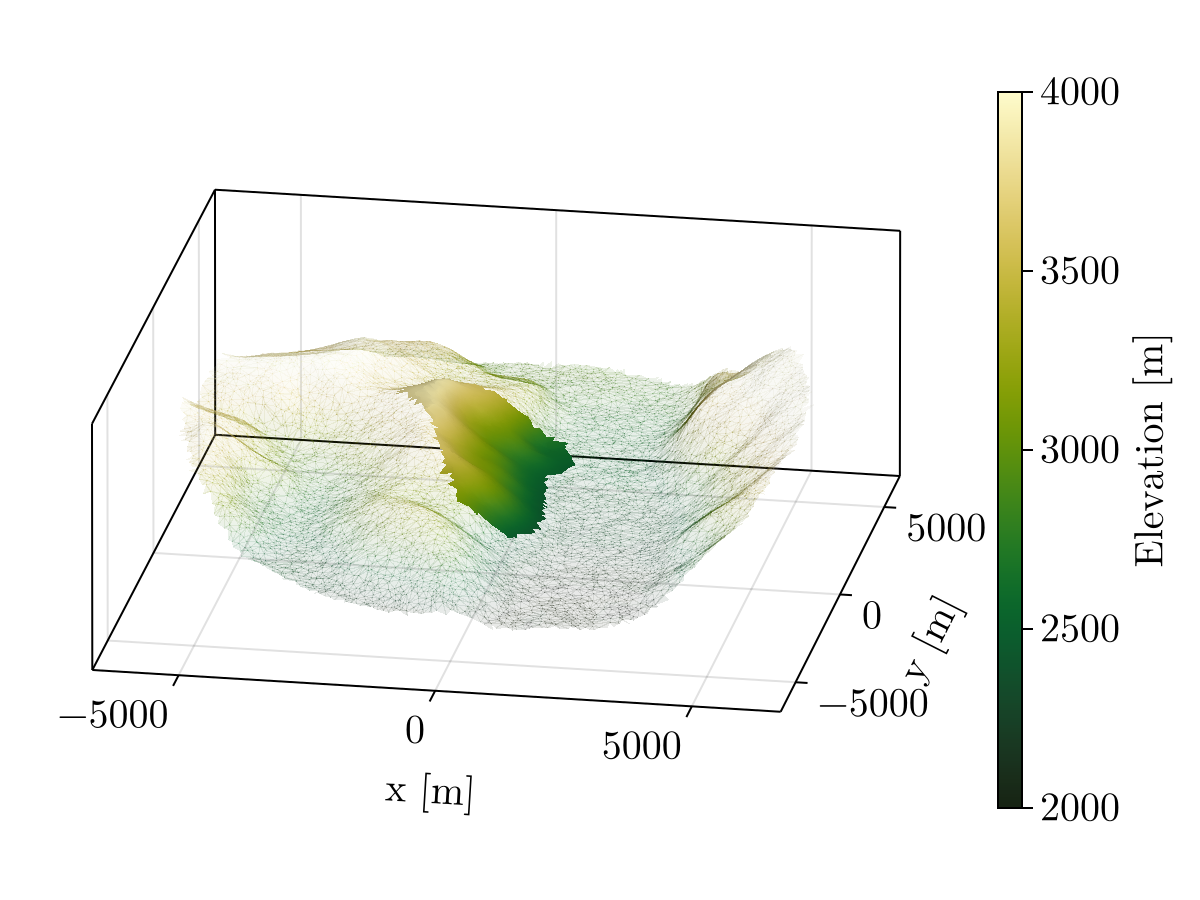

In [10]:
zaspect = 4500*Tambo.uparse("m") / (2 * radius)
    
fig = Figure()
ax = Axis3(
    fig[1, 1],
    azimuth=deg2rad(-80),
    elevation=deg2rad(20),
    aspect=(1, 1, zaspect),
    zgridvisible=false,
    zlabelvisible=false,
    zticklabelsvisible=false,
    zticksvisible=false,
    xlabel="x [m]",
    ylabel="y [m]",
#         margins = (50, 50, 50, 50)
)
zlims!(ax, 1000, 5500)
    
triangles = filter(triangle->norm(Tambo.centroid(triangle)[1:2]) < radius, earth.topography)
triangles = filter(triangle->Tambo.centroid(triangle)[3] > 0 * u"km", triangles)

vxs, faces = Tambo.triangles_to_mesh(triangles)

m = mesh!(
    ax,
    map(vx->Point3f(ustrip.(vx.point)), vxs),
    faces,
    color=[v.point.z.val for v in vxs],
    colormap=Reverse(:speed),
    colorrange=[2000, 4000],
    alpha=0.1
)

longlats = Tuple{Float64, Float64}[]
for triangle in earth.topography
    c = Tambo.centroid(triangle)
    long, lat = Tambo.cart_to_longlat(c)
    push!(longlats, (long, lat))
end

triangles = earth.topography[is_in_outline.(Ref(outline), longlats)]

vxs, faces = Tambo.triangles_to_mesh(triangles)

m = mesh!(
    ax,
    map(vx->Point3f(ustrip.(vx.point)), vxs),
    faces,
    color=[v.point.z.val for v in vxs],
    colormap=Reverse(:speed),
    colorrange=[2000, 4000]
) 

# Axis 3: colorbar
colorbar = Colorbar(fig[1,2], m, label="Elevation [m]")
    
fig

In [ ]:
idxs = findall(is_in_outline.(Ref(outline), longlats))
h5open(filename, "r+") do file
    group = file[key]
    group["detector1"] = idxs
end